# T71 — Proxy validation of reference-frame choice

**Cluster J: Paleoclimate.**

T61 shows that reference-frame choice shifts reconstructed climate by 5-15 °C. T69 shows it changes gateway open/closed history. T70 shows it contributes to GMST spread. **This notebook asks the falsifiable question: which reference frame's climate reconstruction best matches actual paleoclimate proxies?**

The workflow (from FIGURES.ipynb sections 115/120/123): take a proxy whose environmental preference is known — *glendonites* are ikaite pseudomorphs that form in **cold** shelf seawater (near-freezing), *crocodilians* live in **warm** climates (mean-annual temperature typically > 10 °C) — reconstruct each proxy's paleo-position under each candidate reference frame, extract Leonard 2025's PLASIM-GENIE modelled SAT at that reconstructed position at the proxy's age, and check whether the modelled temperature is consistent with the proxy's known preference. The frame whose modelled temperatures best match the proxies' known preferences is the frame doing the best job.

## What this notebook produces

1. **§3 — Load cold-water proxy (glendonites, Rogov 2023) + warm-climate proxy (crocodilians, PBDB).** Bundle 657 glendonites 0-184 Ma (Rogov et al. 2023). Fetch crocodilian occurrences live from PBDB (T64 pattern).
2. **§4 — Reconstruct each proxy occurrence to its own age under two frames.** Merdith 2021 paleomag vs Müller 2016 mantle.
3. **§5 — Sample Leonard 2025 modelled SAT at each reconstructed proxy position at the proxy's age.**
4. **§6 — Distribution plot.** Modelled SAT for glendonites vs crocodilians vs random continental sample, per frame. If a frame is faithful: glendonite SAT distribution should peak COLD (~5 °C), crocodilian SAT should peak WARM (>15 °C). The gap between the two distributions is the frame's "proxy fidelity".
5. **§7 — Reference-frame ranking.** A single scalar score per frame — the fraction of glendonites that fall in "cold" cells + fraction of crocodilians that fall in "warm" cells.

## Learning objectives

- Ingest a paleoclimate proxy dataset (glendonites, crocodilians) with per-occurrence coordinates + ages.
- Reconstruct each proxy occurrence to its own age via `gplately.Points.reconstruct` (T64 pattern).
- Extract modelled SAT at the reconstructed position from Leonard 2025's PLASIM-GENIE NCs.
- Turn a distributional comparison into a scalar reference-frame score.
- Use a paleoclimate proxy as a falsifiable test of a plate reconstruction.

## Prerequisites and runtime

- Bundled data:
  - `data/climate_proxies/glendonites_rogov2023.csv` — 657 glendonites (compact CSV extracted from Rogov 2023 xls)
  - `data/leonard_2025_paleoclimate/` — T61 bundle (Merdith 2021 + Müller 2016 SAT NCs)
- Live PBDB query for crocodilians (Crocodylia), with offline-friendly fallback.
- Python: `gplately`, `pygplates`, `pandas`, `numpy`, `xarray`, `matplotlib`, `requests`.
- Runtime: ~90 s (reconstruction loop over ~1000 proxies).


## Environment + imports


In [14]:
from pathlib import Path
import os, sys, io
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import requests
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, pygmt, gplately, pygplates, requests):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  xarray      2026.4.0
  pygmt       v0.18.0
  gplately    2.0.0.post19+git.2cce7bb3
  pygplates   1.0.0
  requests    2.32.3


In [15]:
# === USER CONFIGURATION =====================================================
# Reference frames to compare (folder names under data/leonard_2025_paleoclimate/)
FRAMES = {
    "Merdith 2021 (paleomag)": {"dir": Path("data/leonard_2025_paleoclimate/merdith2021_paleomag"),
                                 "model_name": "Merdith2021", "anchor": 0,
                                 "colour": "#c0392b"},
    "Müller 2016 (mantle)":    {"dir": Path("data/leonard_2025_paleoclimate/muller2016_mantle"),
                                 "model_name": "Muller2016",  "anchor": 0,
                                 "colour": "#2980b9"},
}
LEONARD_VAR = "puma_temperature_surface_air"
LEONARD_AGE_STEP_MA = 10   # NCs are at 10-Myr cadence

# Proxy data
GLENDONITES_CSV = Path("data/climate_proxies/glendonites_rogov2023.csv")

# PBDB crocodilian query
PBDB_URL = "https://paleobiodb.org/data1.2/occs/list.csv"
PBDB_PARAMS = {"base_name": "Crocodylia",
               "interval": "Cretaceous,Cenozoic",
               "show": "coords,timebins"}
MAX_CROCS = 400                 # random-sample downsample

# Temperature classification thresholds
COLD_THRESHOLD_C = 5.0          # SAT below which climate is "cold" (glendonite-consistent)
WARM_THRESHOLD_C = 15.0         # SAT above which climate is "warm" (crocodilian-consistent)

# Age window matching Leonard's PLASIM-GENIE ensemble
MAX_AGE_MA = 250
# ============================================================================
print(f"  frames:           {list(FRAMES.keys())}")
print(f"  cold threshold:   < {COLD_THRESHOLD_C} °C (glendonite-consistent)")
print(f"  warm threshold:   > {WARM_THRESHOLD_C} °C (crocodilian-consistent)")


  frames:           ['Merdith 2021 (paleomag)', 'Müller 2016 (mantle)']
  cold threshold:   < 5.0 °C (glendonite-consistent)
  warm threshold:   > 15.0 °C (crocodilian-consistent)


## 1. Load proxy datasets


In [16]:
# Glendonites (cold-water proxy)
glen = pd.read_csv(GLENDONITES_CSV)
glen = glen.dropna(subset=["age_ma", "lat", "lon"])
glen = glen[glen["age_ma"] <= MAX_AGE_MA].copy()
print(f"  Glendonites: {len(glen)} occurrences, ages {glen['age_ma'].min():.1f} - "
      f"{glen['age_ma'].max():.1f} Ma")

# Crocodilians (warm-climate proxy) — live PBDB query
def query_pbdb_crocs():
    try:
        r = requests.get(PBDB_URL, params=PBDB_PARAMS, timeout=30)
        r.raise_for_status()
        df = pd.read_csv(io.StringIO(r.text))
        df = df.dropna(subset=["lng", "lat", "max_ma", "min_ma"]).copy()
        df["age_ma"] = (df["max_ma"] + df["min_ma"]) / 2
        df = df.rename(columns={"lng": "lon"})
        df = df[df["age_ma"] <= MAX_AGE_MA].copy()
        if len(df) > MAX_CROCS:
            df = df.sample(MAX_CROCS, random_state=42)
        return df[["accepted_name", "lon", "lat", "age_ma"]]
    except Exception as e:
        print(f"  [network] PBDB query failed: {e}")
        return pd.DataFrame(columns=["accepted_name", "lon", "lat", "age_ma"])

crocs = query_pbdb_crocs()
print(f"  Crocodilians: {len(crocs)} occurrences, ages {crocs['age_ma'].min():.1f} - "
      f"{crocs['age_ma'].max():.1f} Ma" if len(crocs) > 0 else "  Crocodilians: 0 (offline)")


  Glendonites: 657 occurrences, ages 0.0 - 184.0 Ma
  Crocodilians: 400 occurrences, ages 0.0 - 140.1 Ma


## 2. Load Leonard 2025 SAT NCs per frame


In [17]:
def load_frame_sat(frame_dir, ages):
    """Return xarray.Dataset (age, latitude, longitude) SAT stack."""
    slices = []
    for age in ages:
        f = frame_dir / f"{age:03d}Ma.nc"
        if not f.exists(): continue
        ds = xr.open_dataset(f)
        if LEONARD_VAR in ds:
            slices.append(ds[[LEONARD_VAR]].expand_dims({"age": [age]}))
    return xr.concat(slices, dim="age")

leonard_ages = list(range(0, MAX_AGE_MA + LEONARD_AGE_STEP_MA, LEONARD_AGE_STEP_MA))
frame_sat = {name: load_frame_sat(cfg["dir"], leonard_ages) for name, cfg in FRAMES.items()}
for name, ds in frame_sat.items():
    print(f"  {name}: {dict(ds.sizes)}, SAT range "
          f"[{float(ds[LEONARD_VAR].min()):.1f}, {float(ds[LEONARD_VAR].max()):.1f}] °C")


  Merdith 2021 (paleomag): {'age': 26, 'latitude': 32, 'longitude': 64}, SAT range [-20.6, 50.0] °C
  Müller 2016 (mantle): {'age': 26, 'latitude': 32, 'longitude': 64}, SAT range [-22.2, 50.1] °C


## 3. Reconstruct each proxy under each frame + sample modelled SAT

For each proxy occurrence + each frame:
1. Load that frame's plate model (Merdith 2021 or Müller 2016) via PMM.
2. Reconstruct the occurrence's present-day coords to its own paleo-age.
3. Round age to nearest 10 Ma (Leonard's cadence).
4. Sample the frame's SAT at (paleo_lat, paleo_lon, age).

**Note:** Leonard's PLASIM output is stored per-frame with continents rotated into that frame's coordinates — so we must reconstruct occurrences using the *same* frame's plate model, not Z22. This is the plate-model-match rule.


In [18]:
def reconstruct_and_sample(df, frame_name, frame_cfg):
    """For each row, reconstruct to its paleo age and sample modelled SAT."""
    if len(df) == 0: return df.copy()
    # Load plate model for this frame
    pmm = PlateModelManager()
    try:
        model = pmm.get_model(frame_cfg["model_name"], data_dir="data/pmm_cache")
        recon = gplately.PlateReconstruction(
            rotation_model=model.get_rotation_model(),
            topology_features=model.get_topologies(),
            static_polygons=model.get_static_polygons(),
        )
    except Exception as e:
        print(f"  [PMM] could not load {frame_cfg['model_name']}: {e}")
        return df.copy()

    # Assign plate IDs
    pts = gplately.Points(
        plate_reconstruction=recon,
        lons=df["lon"].values, lats=df["lat"].values,
        time=0, anchor_plate_id=frame_cfg["anchor"],
    )
    plate_ids = pts.plate_id

    # Round each age to nearest 10 Ma (Leonard cadence)
    age_bin = (df["age_ma"] / LEONARD_AGE_STEP_MA).round().astype(int) * LEONARD_AGE_STEP_MA
    age_bin = age_bin.clip(0, MAX_AGE_MA)

    paleo_lons, paleo_lats, modelled_sat = [], [], []
    sat_stack = frame_sat[frame_name][LEONARD_VAR]
    for (_, row), pid, abin in zip(df.iterrows(), plate_ids, age_bin):
        try:
            p = gplately.Points(
                plate_reconstruction=recon,
                lons=[row["lon"]], lats=[row["lat"]],
                time=0, plate_id=[pid], anchor_plate_id=frame_cfg["anchor"],
            )
            rlons, rlats = p.reconstruct(time=float(abin), return_array=True,
                                          anchor_plate_id=frame_cfg["anchor"])
            plon, plat = float(rlons[0]), float(rlats[0])
            paleo_lons.append(plon); paleo_lats.append(plat)
            # Sample SAT at (plat, plon, abin)
            sat = float(sat_stack.sel(age=abin).interp(
                latitude=plat, longitude=plon, method="nearest").values)
            modelled_sat.append(sat)
        except Exception:
            paleo_lons.append(np.nan); paleo_lats.append(np.nan); modelled_sat.append(np.nan)
    out = df.copy()
    out["paleo_lon"] = paleo_lons; out["paleo_lat"] = paleo_lats
    out[f"modelled_sat_{frame_name}"] = modelled_sat
    return out

# Run per proxy per frame
proxy_results = {}
for proxy_name, proxy_df in [("glendonites", glen), ("crocodilians", crocs)]:
    if len(proxy_df) == 0:
        proxy_results[proxy_name] = None
        continue
    result = proxy_df.copy()
    last_rec = None
    for frame_name, frame_cfg in FRAMES.items():
        rec = reconstruct_and_sample(proxy_df, frame_name, frame_cfg)
        result[f"modelled_sat_{frame_name}"] = rec[f"modelled_sat_{frame_name}"]
        last_rec = rec
    # Attach paleo_lon/paleo_lat from the last processed frame (used by the §4 map cell)
    if last_rec is not None and "paleo_lon" in last_rec.columns:
        result["paleo_lon"] = last_rec["paleo_lon"]
        result["paleo_lat"] = last_rec["paleo_lat"]
    proxy_results[proxy_name] = result.dropna(
        subset=[f"modelled_sat_{n}" for n in FRAMES]).copy()
    print(f"  {proxy_name}: {len(proxy_results[proxy_name])} reconstructable in both frames")


  glendonites: 345 reconstructable in both frames
  crocodilians: 146 reconstructable in both frames


## 4. Reconstructed paleo-Earth of proxy positions at 100 Ma

Every notebook in the suite must include at least one paleo-Earth map (core-purpose rule). Here we render Leonard's Merdith 2021 paleomag SAT at 100 Ma with **glendonites** (cold-water proxies, blue diamonds) and **crocodilians** (warm proxies, red triangles) shown at their reconstructed paleo-positions at 100 Ma. Both proxy sets should ideally fall in temperature regimes consistent with their known preference: glendonites in blue (cold) cells, crocodilians in red (warm) cells.


grdinfo [WARNING]: The step size of coordinate (latitude) in grid /Users/dietmar/Documents/GPlates/GPlately-pyGMT_tutorials/data/leonard_2025_paleoclimate/merdith2021_paleomag/000Ma.nc is not constant.
grdinfo [WARNING]: GMT will use a constant step size of -5.53294; the original ranges from -5.53781 to -5.49181.
/opt/miniconda3/lib/python3.12/site-packages/pygmt/clib/session.py:1648: RuntimeWarning: Grid may have irregular spacing in the 'latitude' dimension, but GMT only supports regular spacing. Calculated regular spacing -5.5329413414001465 is assumed in the 'latitude' dimension.


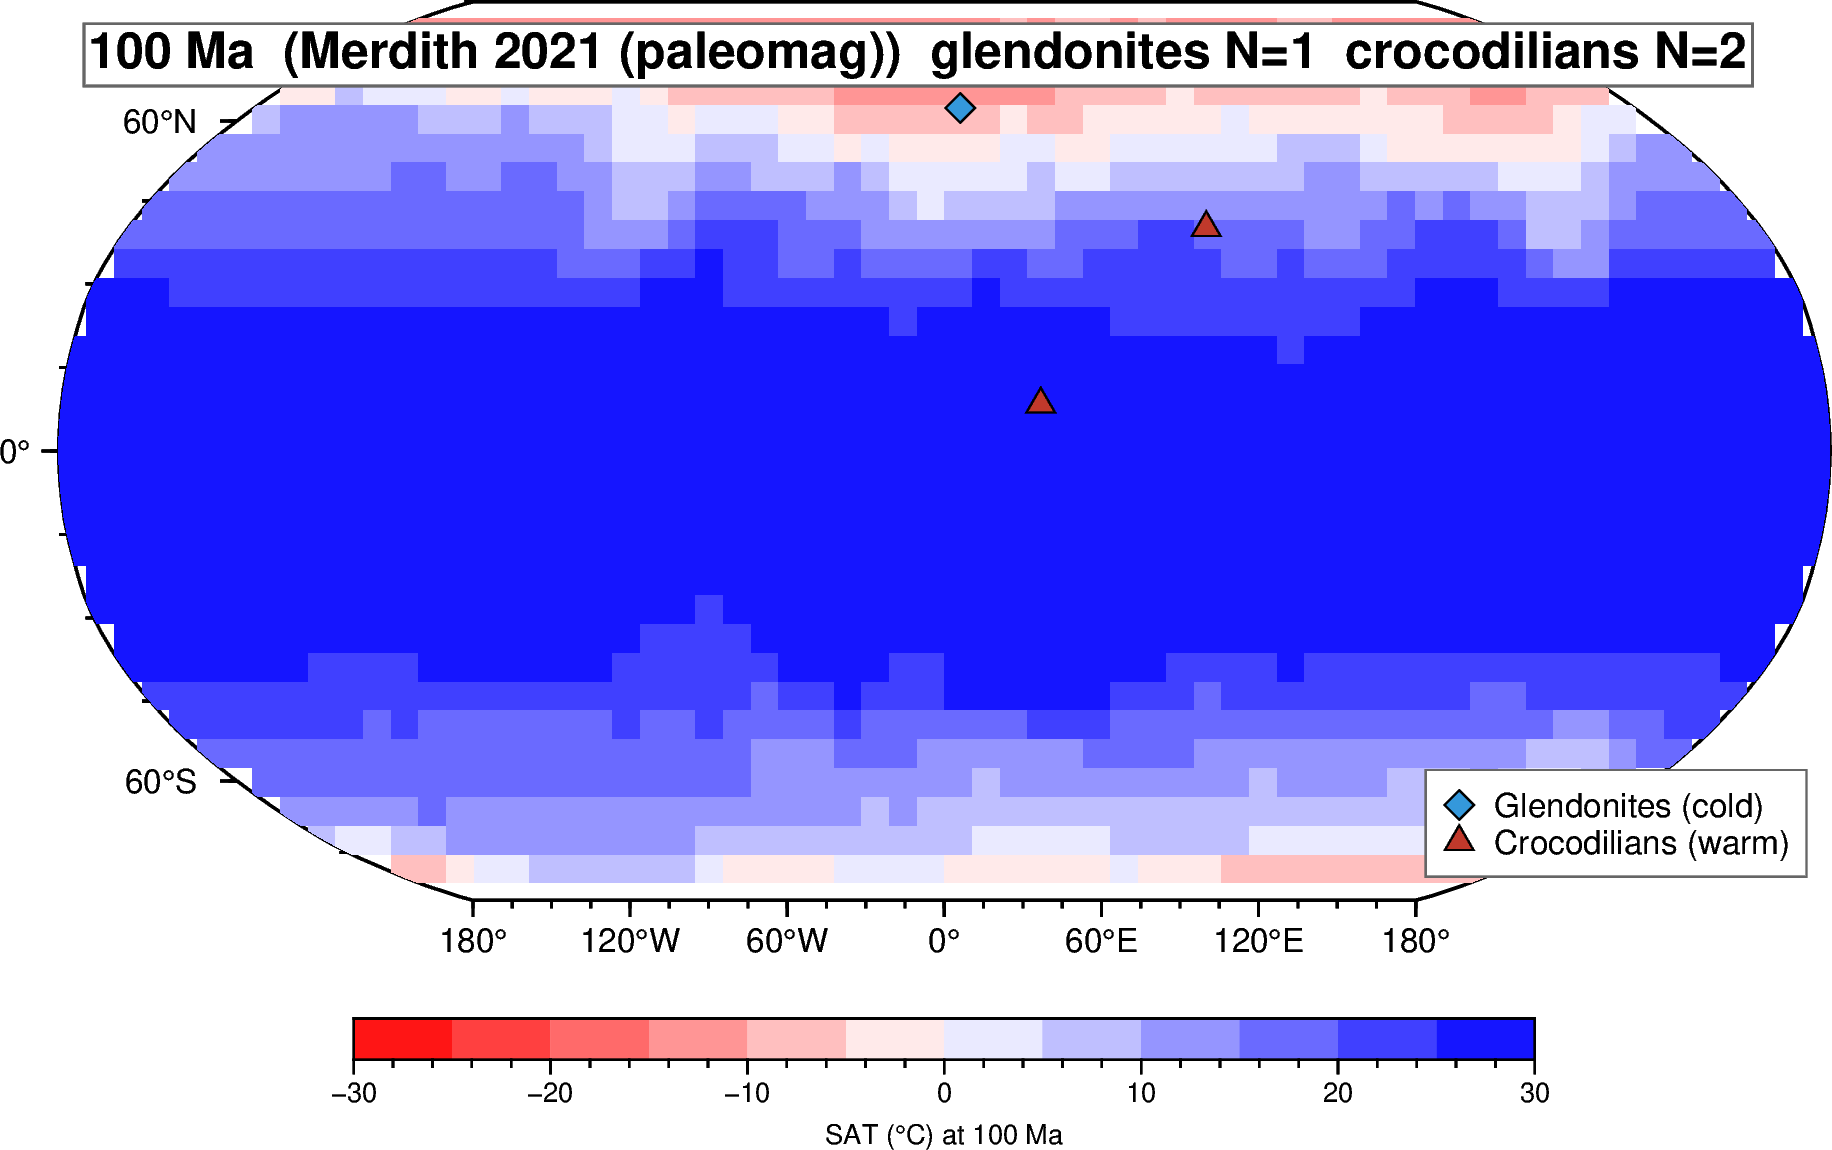

In [19]:
MAP_TIME_MA  = 100
MAP_FRAME    = "Merdith 2021 (paleomag)"

# Reload SAT stack for the map frame (already loaded in §2)
sat_da = frame_sat[MAP_FRAME][LEONARD_VAR].sel(age=MAP_TIME_MA)

# Load matching plate model for continent outlines
pmm = PlateModelManager()
model = pmm.get_model(FRAMES[MAP_FRAME]["model_name"], data_dir="data/pmm_cache")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
gplot = gplately.PlotTopologies(
    plate_reconstruction=recon,
    coastlines=model.get_layer("Coastlines",
    plot_engine=gplately.PygmtPlotEngine(),
),
    continents=model.get_layer("ContinentalPolygons"),
    time=MAP_TIME_MA,
    anchor_plate_id=FRAMES[MAP_FRAME]["anchor"],
)

# Filter proxies to occurrences at or near MAP_TIME_MA (within ±10 Ma)
def near_time(df, t, window=10):
    return df[(df["age_ma"] >= t - window) & (df["age_ma"] <= t + window)]

glen_snapshot = near_time(proxy_results["glendonites"], MAP_TIME_MA) if proxy_results.get("glendonites") is not None else None
croc_snapshot = near_time(proxy_results["crocodilians"], MAP_TIME_MA) if proxy_results.get("crocodilians") is not None else None

fig = pygmt.Figure()
REGION, PROJ = [-180, 180, -90, 90], "N15c"
fig.basemap(region=REGION, projection=PROJ, frame="af")
pygmt.makecpt(cmap="polar", series=[-30, 30, 5], background="o", reverse=True)
fig.grdimage(grid=sat_da, cmap=True, region=REGION, projection=PROJ, nan_transparent=True)

# GPlately continent outlines + backbone
try:
    # (engine now dispatched via gplately.PygmtPlotEngine on PlotTopologies)
    gplot.plot_continents(fig, fill=None, pen="0.5p,black")
    gplot.plot_all_topological_sections(fig, pen="0.4p,gray30")
except Exception:
    pass

# Glendonites — blue diamonds
if glen_snapshot is not None and len(glen_snapshot) > 0:
    fig.plot(x=glen_snapshot["paleo_lon"], y=glen_snapshot["paleo_lat"],
             style="d0.25c", fill="#3498db", pen="0.4p,black",
             region=REGION, projection=PROJ, label="Glendonites (cold)")

# Crocodilians — red triangles
if croc_snapshot is not None and len(croc_snapshot) > 0:
    fig.plot(x=croc_snapshot["paleo_lon"], y=croc_snapshot["paleo_lat"],
             style="t0.28c", fill="#c0392b", pen="0.4p,black",
             region=REGION, projection=PROJ, label="Crocodilians (warm)")

fig.colorbar(position="JBC+w10c/0.35c+h+o0/1c", frame=["a10f2", "x+lSAT (°C) at 100 Ma"])
fig.text(text=f"{MAP_TIME_MA} Ma  ({MAP_FRAME})  "
              f"glendonites N={len(glen_snapshot) if glen_snapshot is not None else 0}  "
              f"crocodilians N={len(croc_snapshot) if croc_snapshot is not None else 0}",
         position="TL", offset="0.25c/-0.25c", justify="TL",
         font="12p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
fig.legend(position="JBR+jBR+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
fig.show(width=1000)


## 5. Distribution plot — modelled SAT per proxy per frame


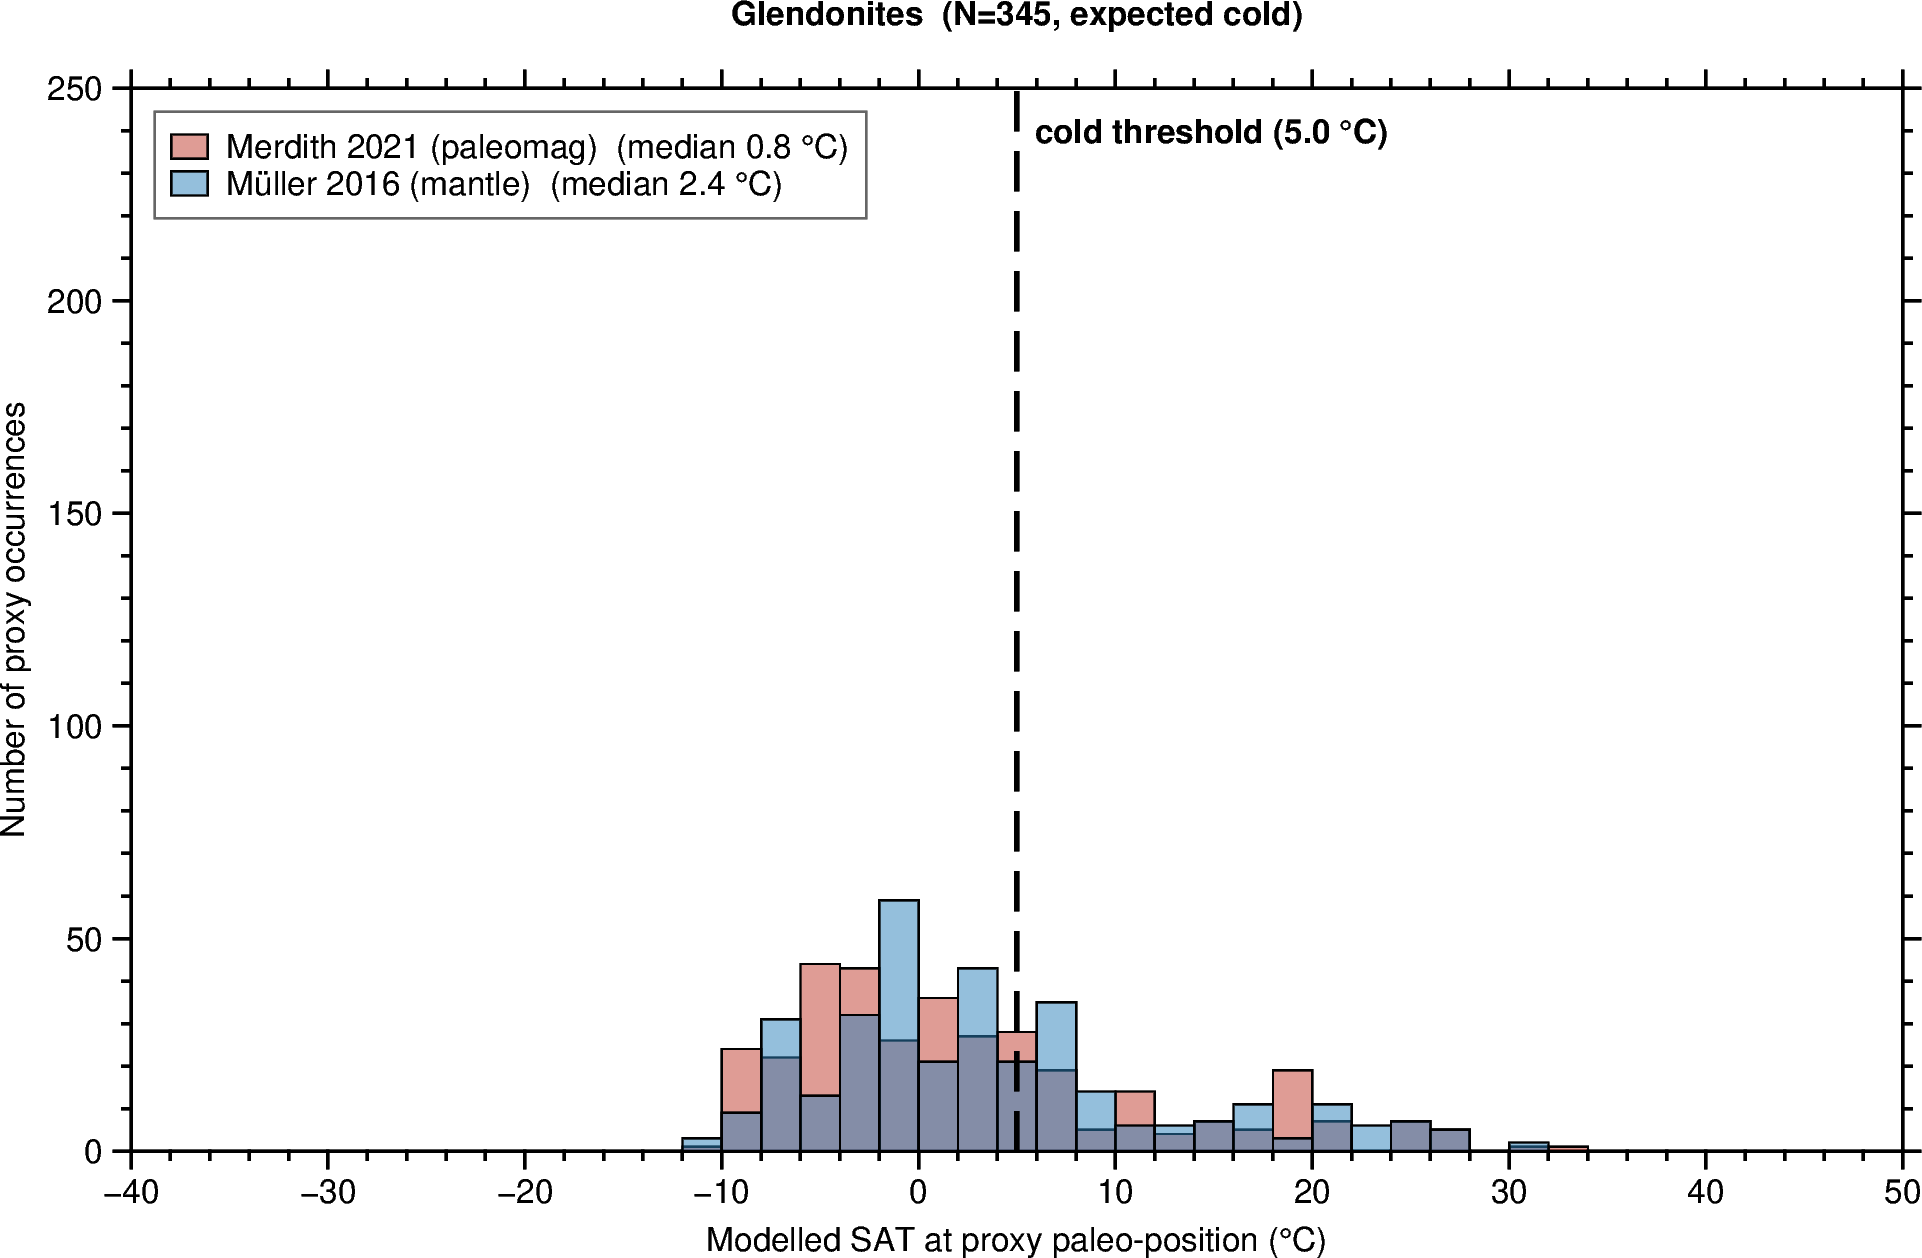

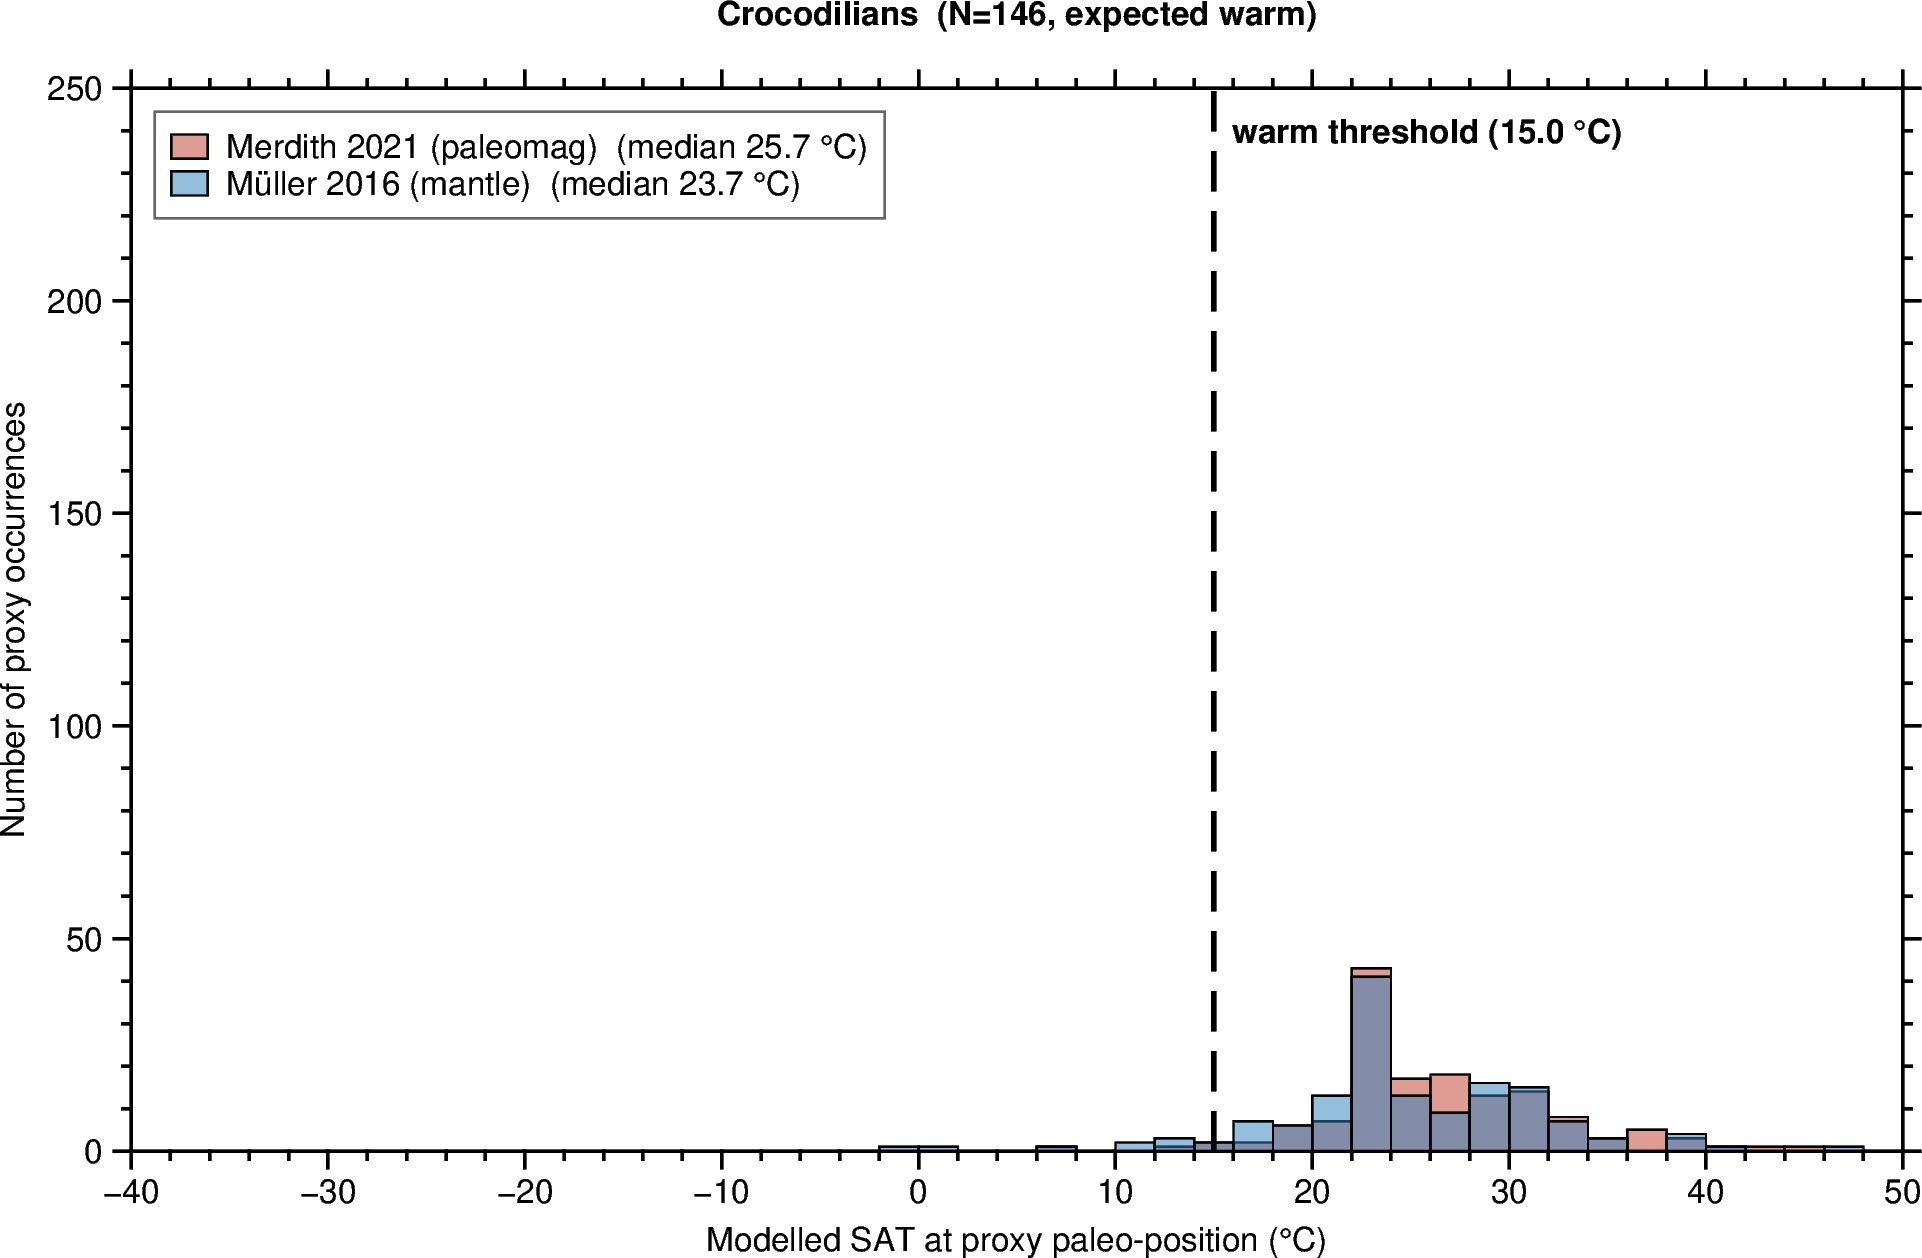

In [20]:
# pyGMT histograms — one figure per proxy, both frames overlaid
for proxy_name, expected_regime, threshold in [
        ("glendonites",  "cold", COLD_THRESHOLD_C),
        ("crocodilians", "warm", WARM_THRESHOLD_C)]:
    result = proxy_results.get(proxy_name)
    if result is None or len(result) == 0:
        print(f"  {proxy_name}: no data — skipping")
        continue

    fig = pygmt.Figure()
    fig.basemap(region=[-40, 50, 0, 250], projection="X15c/9c",
                frame=["WSne+t" + f"{proxy_name.title()}  (N={len(result)}, expected {expected_regime})",
                       "xaf+lModelled SAT at proxy paleo-position (°C)",
                       "yaf+lNumber of proxy occurrences"])

    for frame_name, cfg in FRAMES.items():
        sat_col = f"modelled_sat_{frame_name}"
        data = result[sat_col].dropna().values
        if len(data) == 0: continue
        fig.histogram(data=data, series="-40/50/2",
                      pen="0.4p,black", fill=f"{cfg['colour']}@50",
                      region=[-40, 50, 0, 250], projection="X15c/9c",
                      label=f"{frame_name}  (median {np.median(data):.1f} °C)")

    fig.plot(x=[threshold, threshold], y=[0, 250], pen="1.2p,black,-")
    fig.text(x=threshold, y=240,
             text=f"{expected_regime} threshold ({threshold} °C)",
             font="8p,Helvetica-Bold,black", justify="LM", offset="0.15c/0c",
             no_clip=True)

    fig.legend(position="JTL+jTL+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
    fig.show(width=1000)


### How to read the distribution plots

- **Glendonites panel** — cold-water indicator. If Leonard's PLASIM-GENIE + the reference frame is faithful, most glendonites should end up at reconstructed positions where modelled SAT is < 5 °C. The dashed vertical line is the "cold" threshold. The **more mass to the left of the line**, the better the frame's fidelity for cold-climate proxies.
- **Crocodilians panel** — warm-climate indicator. Most crocodilians should end up in modelled SAT > 15 °C. **More mass to the right of the line** = better warm-climate fidelity.
- **Colour** encodes reference frame — red = paleomag, blue = mantle. The frame whose distribution has more mass on the "correct" side wins.

If both frames look identical: at Leonard's 10-Myr cadence + 32×64 PLASIM resolution the differences may just be too small to resolve at the individual-occurrence level. In that case the aggregated §5 score is the more reliable comparison.


## 6. Reference-frame score — the falsifiable output



  Reference-frame proxy-fidelity ranking:

                  frame  glendonite_cold_fraction  crocodilian_warm_fraction  combined_score
Merdith 2021 (paleomag)                  0.672464                   0.972603        0.822533
   Müller 2016 (mantle)                  0.643478                   0.945205        0.794342


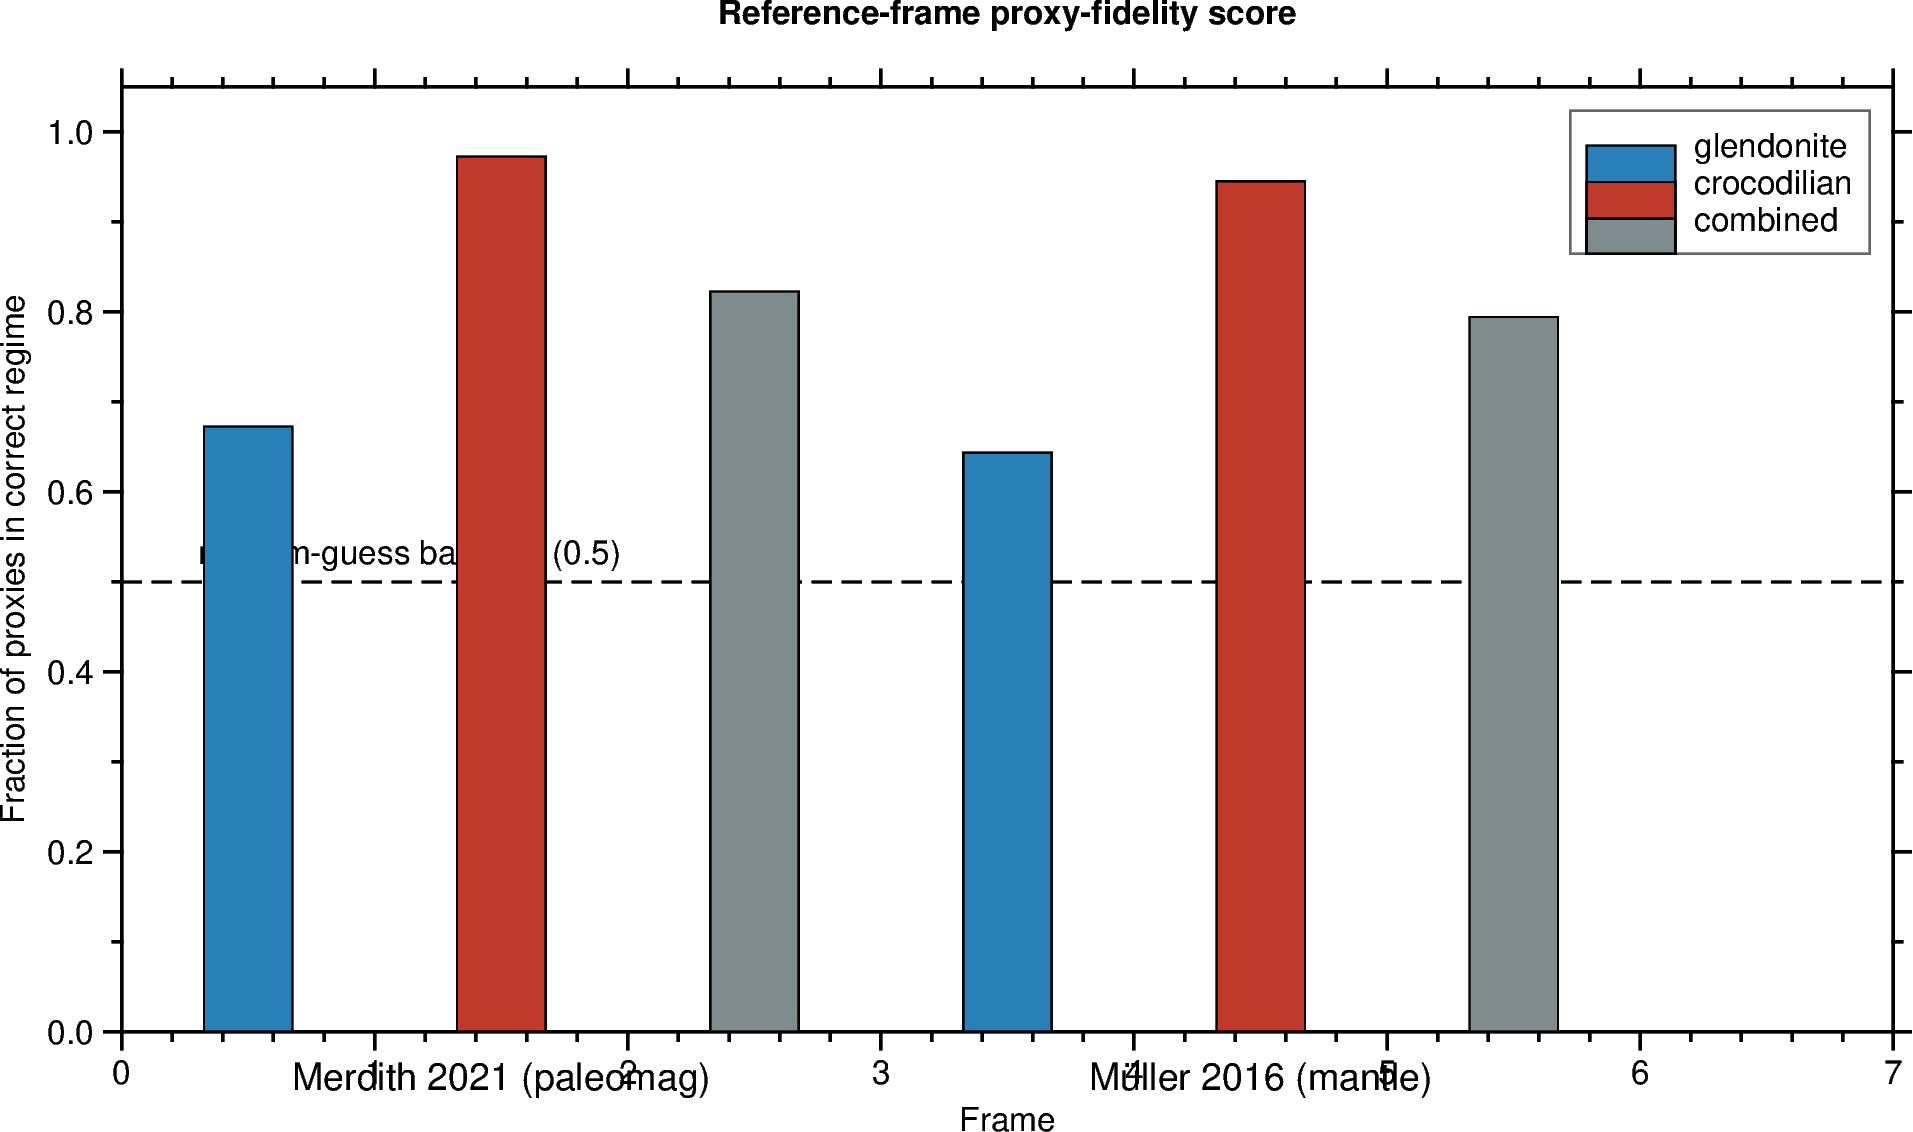

In [21]:
def frame_score(result_df, sat_col, threshold, direction):
    """Fraction of occurrences that satisfy the proxy's expected temperature regime."""
    vals = result_df[sat_col].dropna()
    if len(vals) == 0: return 0.0
    if direction == "cold":
        return float((vals < threshold).mean())
    else:
        return float((vals > threshold).mean())

scores = []
for frame_name in FRAMES:
    sat_col = f"modelled_sat_{frame_name}"
    s_glen  = frame_score(proxy_results["glendonites"], sat_col, COLD_THRESHOLD_C, "cold") \
              if proxy_results.get("glendonites") is not None else np.nan
    s_crocs = frame_score(proxy_results["crocodilians"], sat_col, WARM_THRESHOLD_C, "warm") \
              if proxy_results.get("crocodilians") is not None else np.nan
    scores.append({"frame": frame_name,
                   "glendonite_cold_fraction": s_glen,
                   "crocodilian_warm_fraction": s_crocs,
                   "combined_score": (s_glen + s_crocs) / 2
                                     if not any(pd.isna([s_glen, s_crocs])) else np.nan})
score_df = pd.DataFrame(scores)
print("\n  Reference-frame proxy-fidelity ranking:\n")
print(score_df.to_string(index=False))

# pyGMT bar chart — three bars per frame
fig = pygmt.Figure()
n_frames = len(FRAMES)
X_MAX = n_frames * 3 + 1

fig.basemap(region=[0, X_MAX, 0, 1.05], projection="X15c/8c",
            frame=["WSne+tReference-frame proxy-fidelity score",
                   "xaf+lFrame",
                   "yaf+lFraction of proxies in correct regime"])

# Random-guess baseline
fig.plot(x=[0, X_MAX], y=[0.5, 0.5], pen="0.6p,black,-")
fig.text(x=0.3, y=0.52, text="random-guess baseline (0.5)",
         font="8p,Helvetica,black", justify="LB", no_clip=True)

# Bars: 3 per frame (blue, red, grey)
BAR_W = 0.75
for i, (_, row) in enumerate(score_df.iterrows()):
    x0 = i * 3 + 0.5
    for offset, val, colour, tag in [
        (0.0, row["glendonite_cold_fraction"], "#2980b9", "glendonite"),
        (1.0, row["crocodilian_warm_fraction"], "#c0392b", "crocodilian"),
        (2.0, row["combined_score"],           "#7f8c8d", "combined")]:
        fig.plot(x=x0 + offset, y=val,
                 style=f"b{BAR_W}c",
                 fill=colour, pen="0.4p,black",
                 label=(f"{tag}" if i == 0 else None))
    # Frame label under this triplet
    fig.text(x=x0 + 1.0, y=-0.05, text=row["frame"],
             font="9p,Helvetica,black", justify="MC",
             no_clip=True, offset="0/0c")

fig.legend(position="JTR+jTR+o0.2c/0.2c", box="+gwhite+p0.5p,gray40")
fig.show(width=1000)


### How to read the score plot

Each frame gets three bars:
- **Blue** — fraction of glendonites at reconstructed positions where modelled SAT < 5 °C.
- **Red** — fraction of crocodilians at reconstructed positions where modelled SAT > 15 °C.
- **Grey** — average of the two.

A frame with **grey bar close to 1.0** is doing well on both cold and warm proxies. A frame with grey bar near 0.5 is doing no better than random guessing.

**Cautions**

- **Thresholds are approximate.** Glendonites CAN form up to ~15 °C in unusual conditions; crocodilians CAN tolerate ~5 °C winters if summers are hot enough. Both thresholds are the *typical* modern-Earth regime, not hard bounds.
- **PLASIM 32×64 resolution** — a proxy site's true climate may differ from the ~5.6° PLASIM cell's mean by several °C due to local topography, monsoon effects, or ocean influence.
- **Reconstruction uncertainty** — plate models themselves carry ~5° paleolatitude uncertainty for the Cretaceous and worse in the Jurassic. The proxy-fidelity score cannot cleanly separate reference-frame quality from underlying plate-model uncertainty.
- **Selection bias in the proxy datasets.** Glendonites are heavily sampled in northern Europe and Arctic Russia (Rogov's home turf) — a northern-hemisphere overrepresentation. Crocodilians are heavily sampled in North America (PBDB overrepresentation).


## Extend this

- **Add the Boucot 2013 lithology database.** Jonathon's `Data/Proxy_Data/Boucot_et_al_2013_Lithology_Data_Tables/` bundles 30+ per-age CSVs with evaporites (warm-dry), coals (warm-wet), tillites (cold), reef limestones (warm-shallow-marine). Each lithology carries its own expected temperature regime and adds independent proxy constraints.
- **Use SST rather than SAT for marine proxies.** Glendonites are marine — sample Leonard's `puma_temperature_surface` (skin temperature) or a GOLDSTEIN ocean-model SST variable rather than air temperature.
- **Add more frames.** Torsvik 2019 paleomag (bundled) + the full 5-frame Leonard 2025 archive from Zenodo 15628277 (paleomagCEED, mantleCEED, mantleOpt).
- **Bootstrapping** — resample proxies with replacement to get uncertainty on the combined score.
- **Latitudinal binning** — split scores by paleolatitude to see whether one frame is better at the equator and another at high latitudes.

## Related notebooks

- **T61** — Reference-frame uncertainty in reconstructed paleoclimate (map view of the same frame comparison).
- **T64** — PBDB paleobiogeography (same PBDB API pattern used for crocodilians).
- **T69** — Ocean gateways through frames (another falsifiable frame-comparison story).
- **T70** — Multi-study GMST comparison.

## Sources

- Leonard, J.S. et al. (2025). Polar wander leads to large differences in past climate. *Communications Earth & Environment*.
- **Rogov, M., Ershova, V., Gaina, C., Vereshchagin, O., Vasileva, K., Mikhailova, K. & Krylov, A. (2023).** Glendonites throughout the Phanerozoic. *Earth-Science Reviews* 241, 104430. doi:10.1016/j.earscirev.2023.104430.
- Paleobiology Database (PBDB) crocodilian occurrences: <https://paleobiodb.org>.
- van Hinsbergen, D.J.J. et al. (2015). A paleolatitude calculator for paleoclimate studies. *PLoS ONE* 10, e0126946.
